In [1]:
import numpy as np
import pandas as pd

import math

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns

In [2]:
molecules = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\02-Generate Standard Smile\Valid_12756.csv")

In [3]:
molecules.head(1)

,Molecule ChEMBL ID,MIC,Units,Smiles,Label
0,CHEMBL1086385,0.12,ug.mL-1,CCCCCCCC[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N[C@@H](...,1


In [5]:
summary = molecules["MIC"].describe()
print(summary)

count    12756.000000
mean        40.811497
std         92.237210
min          0.000190
25%          3.120000
50%         12.500000
75%         50.000000
max       3125.000000
Name: MIC, dtype: float64


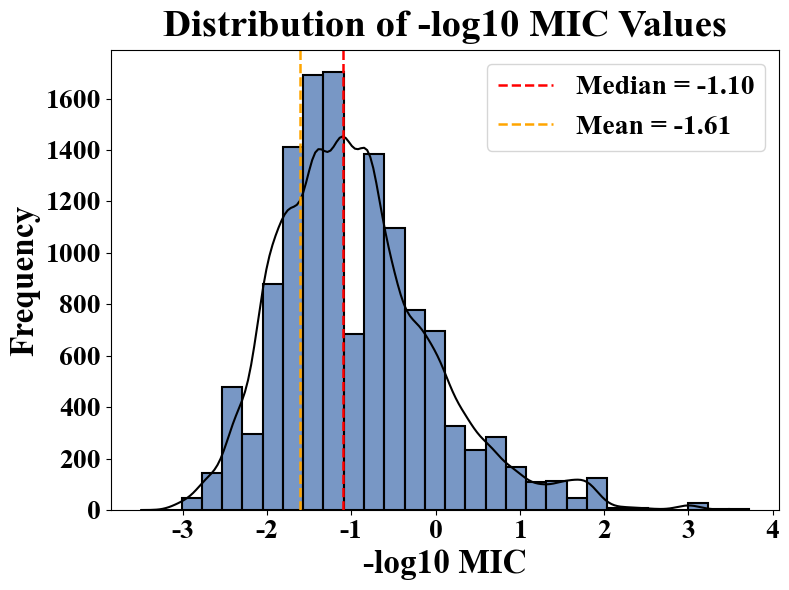

In [6]:
median_val = 12.5
median_log = -np.log10(median_val)
mean_val = 40.81
mean_log = -np.log10(mean_val)

plt.figure(figsize=(8, 6))

ax = sns.histplot(
    data=molecules,
    x=-np.log10(molecules['MIC'] + 1e-6),
    bins=30,
    kde=True,
    color='#4B74B2',
    edgecolor='black',
    alpha=0.75,
    linewidth=1.5,
)

for line in ax.lines:
    line.set_color('black')
    line.set_linewidth(1.5)

plt.axvline(x=median_log, color='red', linestyle='--', linewidth=1.8, 
            label=f'Median = {median_log:.2f}')

plt.axvline(x=mean_log, color='orange', linestyle='--', linewidth=1.8,
            label=f'Mean = {mean_log:.2f}')

plt.title('Distribution of -log10 MIC Values', fontsize=28, pad=10, fontweight='bold')
plt.xlabel('-log10 MIC', fontsize=24, fontweight='bold')
plt.ylabel('Frequency', fontsize=24, fontweight='bold')

plt.yticks(fontsize=20, weight='bold')
plt.xticks(fontsize=20, weight='bold')

plt.legend(prop={'size': 20, 'weight': 'bold'}, frameon=True)

plt.tight_layout()

plt.savefig("Histogram -log10 mic mean median.pdf", format='pdf', bbox_inches='tight')

plt.show()

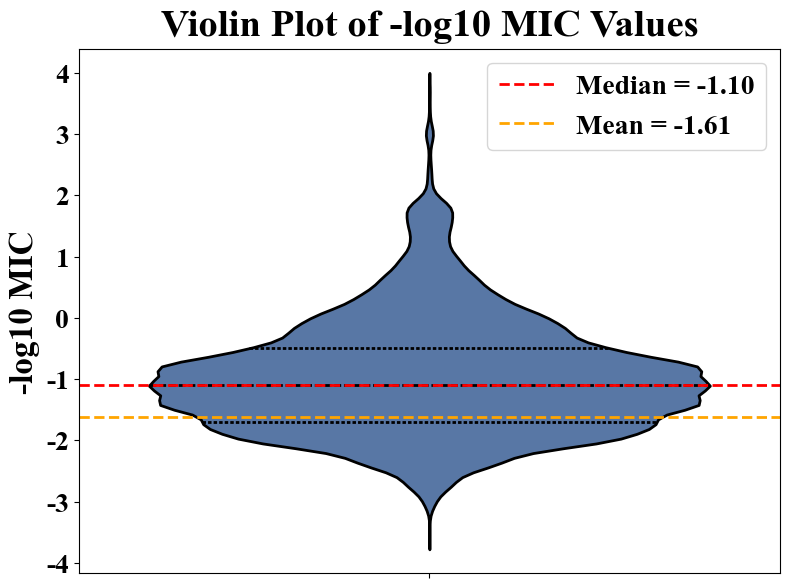

In [9]:
plt.figure(figsize=(8, 6))
sns.violinplot(
    y=-np.log10(molecules['MIC'] + 1e-6),
    color='#4B74B2',
    inner='quartile',
    linewidth=2,
    edgecolor='black'
)

median_log_mic = -np.log10(molecules['MIC'].median())

plt.title('Violin Plot of -log10 MIC Values', fontsize=28, fontweight='bold', pad=10)
plt.ylabel('-log10 MIC', fontsize=24, fontweight='bold')
plt.yticks(fontsize=20, weight='bold')

plt.axhline(
    y=median_log_mic,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median = {median_log:.2f}'
)

plt.axhline(y=mean_log, 
            color='orange', 
            linestyle='--', 
            linewidth=2,
            label=f'Mean = {mean_log:.2f}')

plt.legend(prop={'size': 20, 'weight': 'bold'},loc='upper right', frameon=True)

plt.tight_layout()

plt.savefig("violinplot -log10 mic mean median.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [ ]:
log_mic = -np.log10(molecules['MIC'] + 1e-6)  # 避免 log(0)

# 描述统计
desc_log = log_mic.describe()
median_log = desc_log['50%']

In [15]:
molecules["-log_MIC"] = -np.log10(molecules["MIC"] + 1e-6)
molecules.head(1)

,Molecule ChEMBL ID,MIC,Units,Smiles,Label,-log_MIC
0,CHEMBL1086385,0.12,ug.mL-1,CCCCCCCC[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N[C@@H](...,1,0.920815


In [18]:
threshold = molecules["-log_MIC"].median()
molecules["Labes_log_MIC"] = (molecules["-log_MIC"] < threshold).astype(int)
molecules["Labes_log_MIC"].value_counts()

Labes_log_MIC
0    7116
1    5640
Name: count, dtype: int64